# IMF solver speed: GD threads and single-threaded QuantLet

Compare the lookup-based gradient-descent solver in `gd_irmf.ipynb` with QuantLet's scalar golden-section solver. Both receive the same observations and filtering settings within each test case.

GD uses 1, 2, 4, 8, 12 or 16 threads. QuantLet uses one thread only. The HTML report uses charts and short explanations.


In [1]:
import os
import json
import hashlib
from pathlib import Path
import sys

# Set before importing NumPy. Restart the kernel before rerunning the notebook.
for name in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "BLIS_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[name] = "1"
os.environ["MPLCONFIGDIR"] = "/tmp/imf-benchmark-mpl"
sys.dont_write_bytecode = True
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "experiments/gd-irmf/gd_irmf.ipynb").exists())
EXPERIMENT = ROOT / "experiments/solver-speed"
sys.path.insert(0, str(EXPERIMENT))
import benchmark_support as benchmark
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

GD_WORKERS = [1, 2, 4, 8, 12, 16]
REPEATS = 3
PROFILES = ["your_gd", "quantlet_zero"]

RERUN_BENCHMARK = False  # True runs fresh timings and replaces the saved results.


## What stays the same

- Within a case, both solvers use identical data, kernel, bandwidths and H.
- Both process one signal from the first component to the last. Stages stay in order.
- GD distributes independent local windows across threads. QuantLet runs its original scalar solver on one thread.
- Times include preparing windows, fitting and GD thread-pool startup. Input generation, plots and pooled-reference diagnostics are excluded.
- Both keep their original stopping rules. Numerical agreement and convergence are checked separately.

Each case has one untimed warmup per solver. Three measured runs use shuffled configuration order. The machine is not reserved exclusively, so ranges between runs are shown.


In [2]:
case_parameters = pd.DataFrame([
    {k: v for k, v in benchmark.make_case(profile)["parameters"].items() if k not in ["bandwidths", "input_sha256"]}
    for profile in PROFILES
])
display(case_parameters[["label", "n", "stages", "H", "kernel", "noise"]])
print("Both use an endpoint-exclusive periodic grid. QuantLet's source creates 2001 points including both endpoints; this benchmark uses 2000 unique points.")


,label,n,stages,H,kernel,noise
0,My GD settings,1000,9,0.4,squared_triangular,Gaussian + signed exponential
1,QuantLet default settings,2000,8,1.0,epanechnikov,20% replaced by zero


Both use an endpoint-exclusive periodic grid. QuantLet's source creates 2001 points including both endpoints; this benchmark uses 2000 unique points.


## Small baseline

Check output agreement using the current adapters before reading or rerunning the timings.


In [3]:
small_case = benchmark.make_case("your_gd", n=128)
small_gd = benchmark.decompose(small_case, "gd", 1)
small_scalar = benchmark.decompose(small_case, "quantlet", 1)
small_difference = np.max(np.abs(small_gd["components"] - small_scalar["components"]))
assert small_difference < 1e-4
assert all(stage["unconverged_chunks"] == 0 for stage in small_gd["stages"])
print(f"Maximum component difference: {small_difference:.3g}")


Maximum component difference: 5.38e-07


## Read the timing measurements or run them again

By default, this cell reads the saved measurements. They retain every GD run and only QuantLet's one-thread runs from the original timing session. The timing values and original source hashes are preserved. The JSON records the scope change and current adapter hash separately.

Set `RERUN_BENCHMARK = True` above for fresh timings. This runs 42 measurements and replaces the saved results. QuantLet is always restricted to one worker.


In [4]:
if RERUN_BENCHMARK:
    results = benchmark.run_suite(workers=GD_WORKERS, repeats=REPEATS, profiles=PROFILES)
else:
    results = json.loads((benchmark.OUTPUT / "benchmark.json").read_text())
    assert results["metadata"]["complete"]
    assert results["workers_by_method"] == {"gd": GD_WORKERS, "quantlet": [1]}
    assert results["repeats"] == REPEATS
    assert [case["profile"] for case in results["cases"]] == PROFILES
    # The original solver files must still match the measurement-time hashes.
    for source_path in [benchmark.LOCAL_SOURCE, benchmark.UPSTREAM_SOURCE]:
        recorded = next(item for item in results["metadata"]["sources"] if Path(item["path"]).name == source_path.name)
        assert hashlib.sha256(source_path.read_bytes()).hexdigest() == recorded["sha256"]
    print("Using saved measurements. QuantLet is included only at one thread.")
summary = benchmark.summarize(results)
display(summary.round({"seconds": 4, "minimum": 4, "maximum": 4, "speedup": 2}))


Using saved measurements. QuantLet is included only at one thread.


,case,method,workers,seconds,minimum,maximum,repeats,max_difference,thread_difference,speedup
0,quantlet_zero_2000,gd,1,0.6810,0.6780,0.7125,3,9.329776e-07,0.000000e+00,1.00
1,quantlet_zero_2000,gd,2,0.3772,0.3630,0.3774,3,9.329776e-07,1.221223e-07,1.81
2,quantlet_zero_2000,gd,4,0.2115,0.2079,0.2116,3,9.329776e-07,1.319614e-07,3.22
3,quantlet_zero_2000,gd,8,0.1132,0.1113,0.1149,3,7.769370e-07,5.000133e-07,6.01
4,quantlet_zero_2000,gd,12,0.0893,0.0887,0.0893,3,5.984672e-07,5.000133e-07,7.63
5,quantlet_zero_2000,gd,16,0.0893,0.0854,0.0901,3,5.878530e-07,5.000133e-07,7.62
6,quantlet_zero_2000,quantlet,1,15.5144,15.5129,15.5284,3,0.000000e+00,0.000000e+00,1.00
7,your_gd_1000,gd,1,0.8235,0.8229,0.8539,3,9.103396e-07,0.000000e+00,1.00
8,your_gd_1000,gd,2,0.4316,0.4203,0.4343,3,9.103396e-07,5.565493e-07,1.91
9,your_gd_1000,gd,4,0.2327,0.2320,0.2366,3,9.103396e-07,5.565493e-07,3.54


## Check that speed did not change the answer

GD thread chunks can stop at slightly different iterations. Every measured output was checked against the single-thread scalar reference. Runs with unfinished GD chunks were rejected.


In [5]:
runs = pd.DataFrame(results["runs"])
assert results["metadata"]["complete"]
assert len(runs) == len(PROFILES) * (len(GD_WORKERS) + 1) * REPEATS
assert (runs.loc[runs.method == "quantlet", "workers"] == 1).all()
assert (runs.groupby(["case", "method", "workers"]).size() == REPEATS).all()
assert (runs.unconverged_chunks == 0).all()
assert runs.max_component_difference_from_scalar.max() < 1e-4
print(f"All {len(runs)} timing runs passed.")
print(f"Largest solver difference: {runs.max_component_difference_from_scalar.max():.3g}")
print(f"Largest thread-related difference: {runs.max_component_difference_from_single_thread.max():.3g}")
display(pd.DataFrame(results["validation"]))


All 42 timing runs passed.
Largest solver difference: 9.33e-07
Largest thread-related difference: 5.57e-07


,case,method,reconstruction_max_error,unconverged_chunks,cross_solver_max_component_difference,native_gd_adapter_max_difference
0,your_gd_1000,gd,4.440892e-16,0.0,NaN,NaN
1,your_gd_1000,quantlet,3.330669e-16,0.0,NaN,NaN
2,your_gd_1000,NaN,NaN,NaN,9.103396e-07,NaN
3,your_gd_1000,NaN,NaN,NaN,NaN,2.959872e-17
4,quantlet_zero_2000,gd,4.440892e-16,0.0,NaN,NaN
5,quantlet_zero_2000,quantlet,4.440892e-16,0.0,NaN,NaN
6,quantlet_zero_2000,NaN,NaN,NaN,9.329776e-07,NaN


## Full decomposition as the signal grows

I keep the GD notebook defaults at every size: sigma = 0.2, H = 2 × sigma = 0.4, signed exponential contamination with probability 0.2 and scale 0.2, and the squared-triangular kernel. Both solvers receive identical observations and windows at each size.

The 10 sizes are evenly spaced from 1,000 to 20,000 points, rounded to integers. The original window schedule starts near half the signal length and shrinks to 31 points, so larger signals have more stages. This measures the full default workflow.

My GD uses 1, 4 and 12 threads at all 10 sizes. QuantLet uses one thread. The original sweep stopped QuantLet at 5,222 points; a later extension measures larger sizes while reusing all GD timings. The extension has its own 40-minute wall-clock limit and discards partial timings. Completed results and component checks are saved after every size.

Each configuration has one measured run after warmup. Both switches below default to reading the cached results. `RERUN_SIZE_SWEEP` runs or resumes the original sweep; `EXTEND_QUANTLET` adds missing scalar runs up to `QUANTLET_EXTENSION_MAX_N`. To replace the original sweep, first move `results/scaling.json` aside. Larger scalar runs can take several minutes each.

In [6]:
from scaling_benchmark import run_scaling, summarize as summarize_scaling
from extend_quantlet import extend

RERUN_SIZE_SWEEP = False
EXTEND_QUANTLET = False
QUANTLET_EXTENSION_MAX_N = 13667
if RERUN_SIZE_SWEEP:
    scaling_results = run_scaling()
else:
    scaling_results = json.loads((benchmark.OUTPUT / "scaling.json").read_text())
if EXTEND_QUANTLET:
    scaling_results = extend(max_n=QUANTLET_EXTENSION_MAX_N, budget_seconds=2400)
assert scaling_results["metadata"]["complete"]
assert len(scaling_results["sizes"]) == 10
quantlet_max_n = scaling_results["metadata"]["quantlet_max_n"]
expected_runs = {(n, method, workers) for n in scaling_results["sizes"]
                 for method, workers in [("quantlet", 1), ("gd", 1), ("gd", 4), ("gd", 12)]
                 if method != "quantlet" or n <= quantlet_max_n}
actual_runs = {(run["n"], run["method"], run["workers"]) for run in scaling_results["runs"]}
assert len(scaling_results["runs"]) == len(expected_runs) and actual_runs == expected_runs
assert all(case["H"] == 2 * case["sigma"] == 0.4 for case in scaling_results["cases"])
assert scaling_results["metadata"]["all_output_checks_passed"]
assert all(check.get("scalar_reference_available", check["max_component_difference"] is not None) == (check["n"] <= quantlet_max_n)
           for check in scaling_results["validation"])
scaling_summary = summarize_scaling(scaling_results)
display(scaling_summary.pivot(index="n", columns=["method", "workers"], values="seconds").round(3).fillna("Not measured"))
print(f"One measured full decomposition per configuration. All {len(actual_runs)} applicable output checks passed.")
print(f"Scalar comparisons cover sizes through {quantlet_max_n:,} points.")
for extension in scaling_results["metadata"].get("quantlet_extensions", []):
    print(f"QuantLet extension: {extension['status']}, {extension['elapsed_wall_seconds'] / 60:.1f} minutes, {extension['completed_sizes']}")

method        gd                      quantlet
workers       1       4       12            1 
n                                             
1000       0.855   0.235   0.097         6.207
3111       8.973   2.394   0.812        46.202
5222      23.474   6.436   2.256       116.858
7333      46.703  12.604   4.295       216.712
9444      77.012  20.792   7.129        350.21
11556    116.344  31.013  10.677        511.22
13667    161.061  43.797  14.761       714.944
15778    208.943  57.414  19.891  Not measured
17889    286.315  77.810  26.485  Not measured
20000    348.813  95.485  32.635  Not measured

One measured full decomposition per configuration. All 37 applicable output checks passed.
Scalar comparisons cover sizes through 13,667 points.
QuantLet extension: completed, 30.0 minutes, [7333, 9444, 11556, 13667]


## Fit the scaling law

I fit **time = a × (points / 1,000)^p** by fitting a straight line in log–log space. If p is 1, doubling the points doubles the time. If p is 2, doubling the points multiplies the time by 4.

Each fit uses all measured sizes for that curve. The shared-range fit uses only sizes also measured with QuantLet. These are descriptions of the observed range, not proven complexity bounds. With one timing per size, they do not estimate run-to-run variation. The default stage count and window sizes grow with the signal.

The HTML chart switches between linear and log–log axes. Dashed fits can be hidden and never extend beyond measured endpoints.

The report also switches between seconds and time relative to each method at 1,000 points. In the relative view, all measured curves start at 1. A value of 100 means that method takes 100 times as long as its own baseline. Fitted curves are normalized by their own fitted baseline, preserving their powers and also starting at 1. This separates proportional growth from waiting time.

In [7]:
from scaling_charts import fit_power_law, fit_scaling, save_fits

# Check the fit against a known power law, independent of the timing data.
known_n = np.array([1000, 2000, 4000, 8000, 16000])
known = fit_power_law(known_n, 3 * (known_n / 1000) ** 2)
assert np.isclose(known["power"], 2) and np.isclose(known["seconds_at_1000"], 3)
assert np.isclose(known["doubling_factor"], 4)

scaling_fits = fit_scaling(scaling_results)
save_fits(scaling_fits, benchmark.OUTPUT)
display(pd.DataFrame([
    {"Solver": fit["label"], "Measured sizes": fit["point_count"],
     "Largest n": fit["n_max"], "Power p": fit["power"],
     "Time multiplier for 2x points": fit["doubling_factor"],
     "R squared in log space": fit["r_squared_log"],
     "Power p over shared range": fit["shared_range_fit"]["power"]}
    for fit in scaling_fits["fits"]
]).round(4))

from scaling_charts import normalized_timings
relative_times = normalized_timings(scaling_results)
assert (relative_times.loc[relative_times.n == 1000, "time_multiple"] == 1).all()
assert np.allclose(relative_times.time_multiple * relative_times.baseline_seconds, relative_times.seconds)
print(f"Waiting time and relative growth at {quantlet_max_n:,} points:")
display(relative_times.loc[relative_times.n == quantlet_max_n,
                          ["method", "workers", "seconds", "time_multiple"]].round(3))

,Solver,Measured sizes,Largest n,Power p,Time multiplier for 2x points,R squared in log space,Power p over shared range
0,QuantLet · 1 thread,7,13667,1.8101,3.5066,0.9997,1.8101
1,My GD · 1 thread,10,20000,1.9969,3.9914,0.9998,1.9964
2,My GD · 4 threads,10,20000,1.9961,3.9893,0.9999,1.9903
3,My GD · 12 threads,10,20000,1.9458,3.8525,0.9997,1.9242


Waiting time and relative growth at 13,667 points:


,method,workers,seconds,time_multiple
22,gd,1,161.061,188.404
23,gd,4,43.797,186.120
21,gd,12,14.761,152.000
36,quantlet,1,714.944,115.190


## Charts and short HTML report

The report keeps the two test cases separate. Different settings change the work involved, so compare solvers within the same case. The settings comparison also lists the newer real-vs-calculated and residual-distribution notebooks.


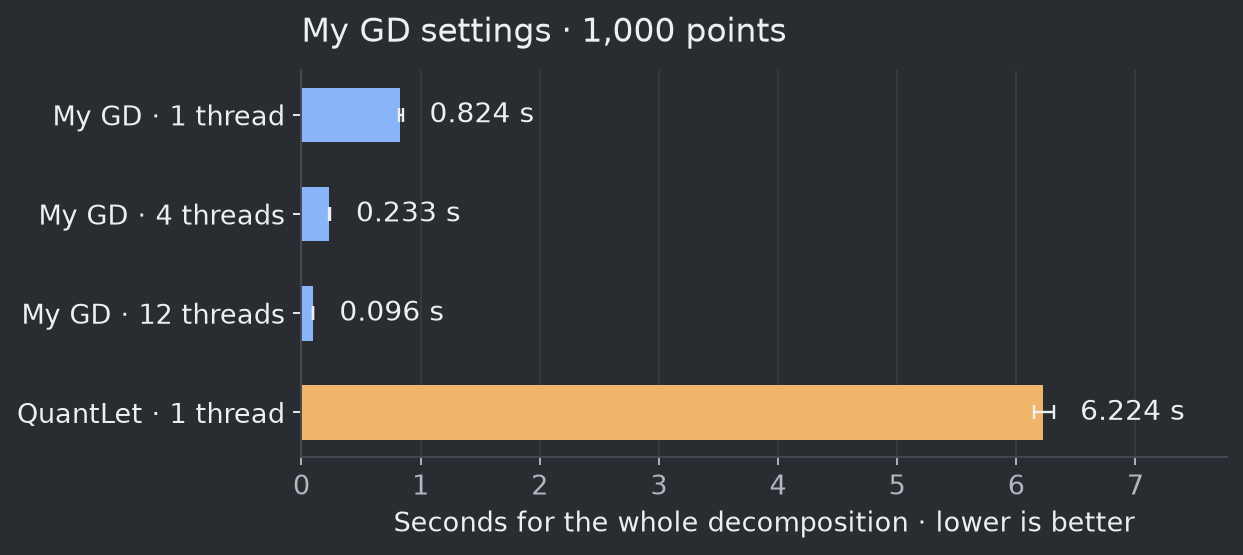

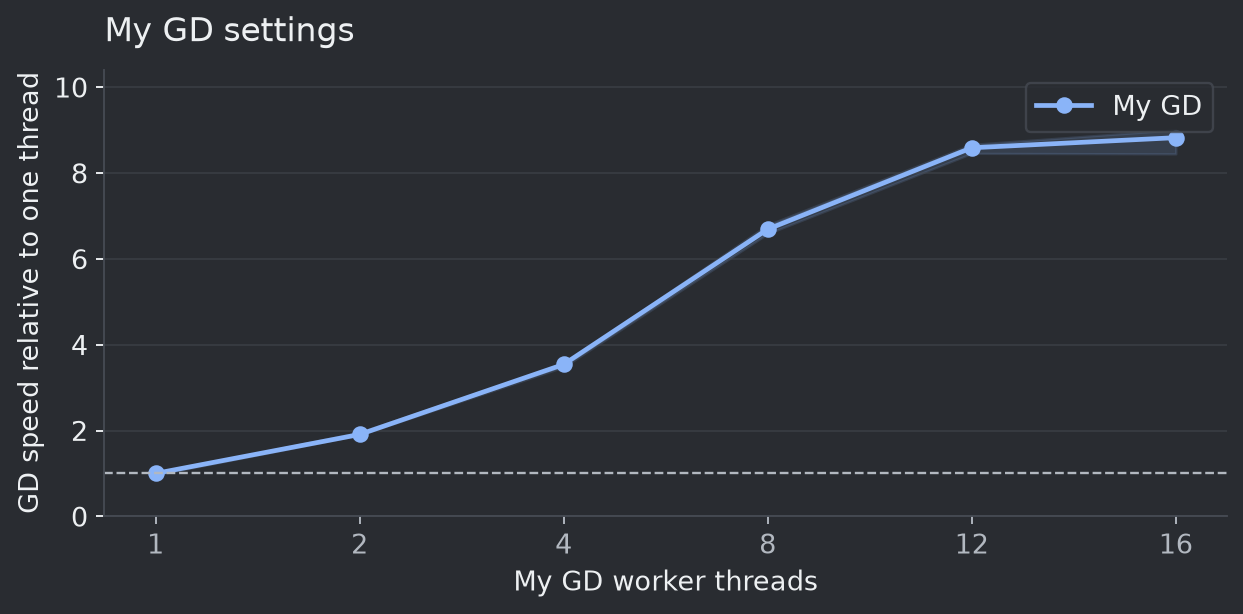

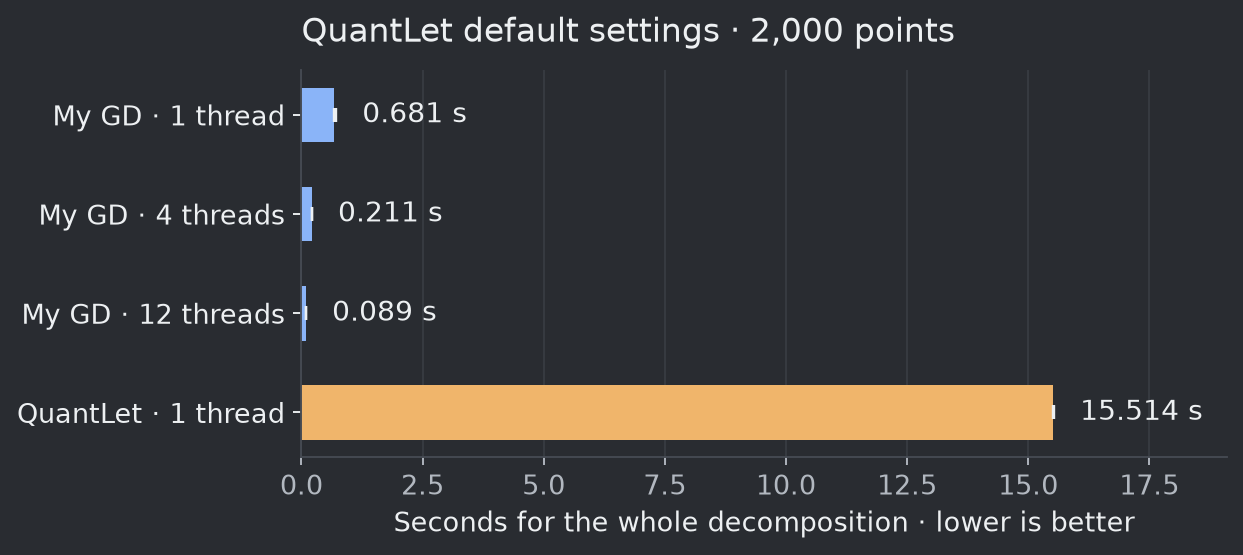

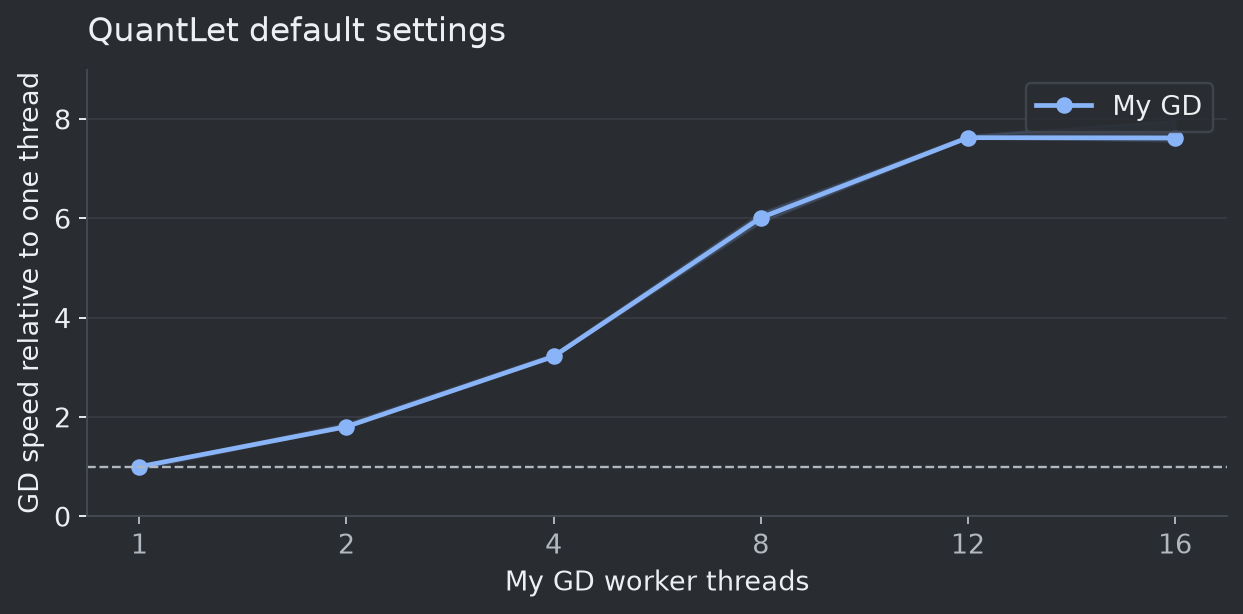

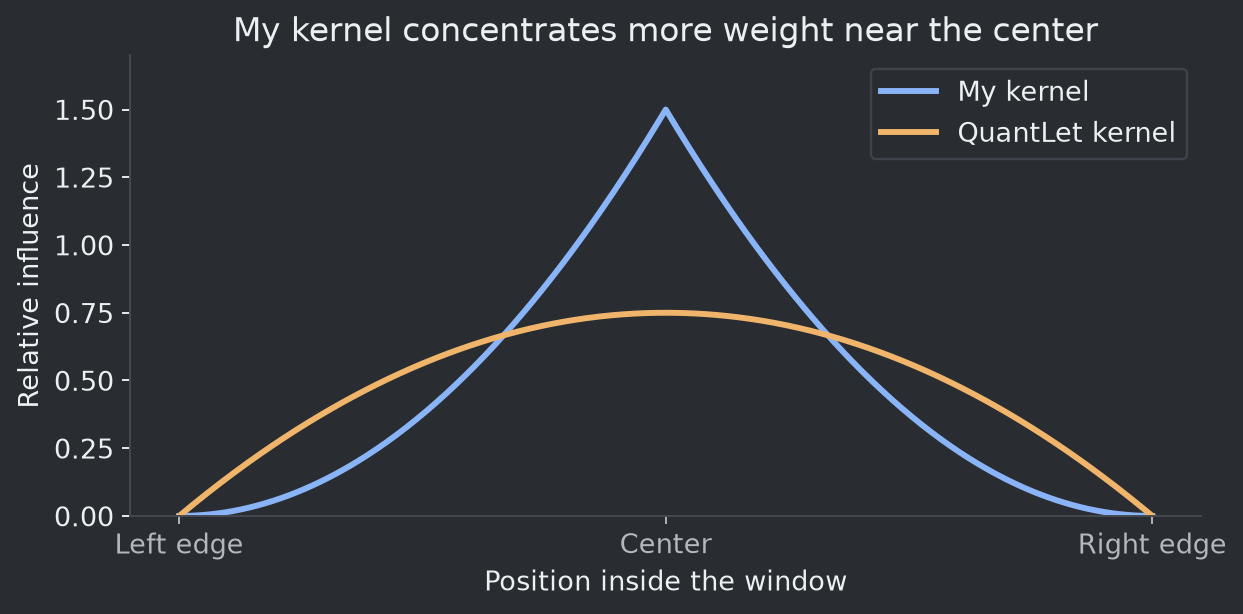

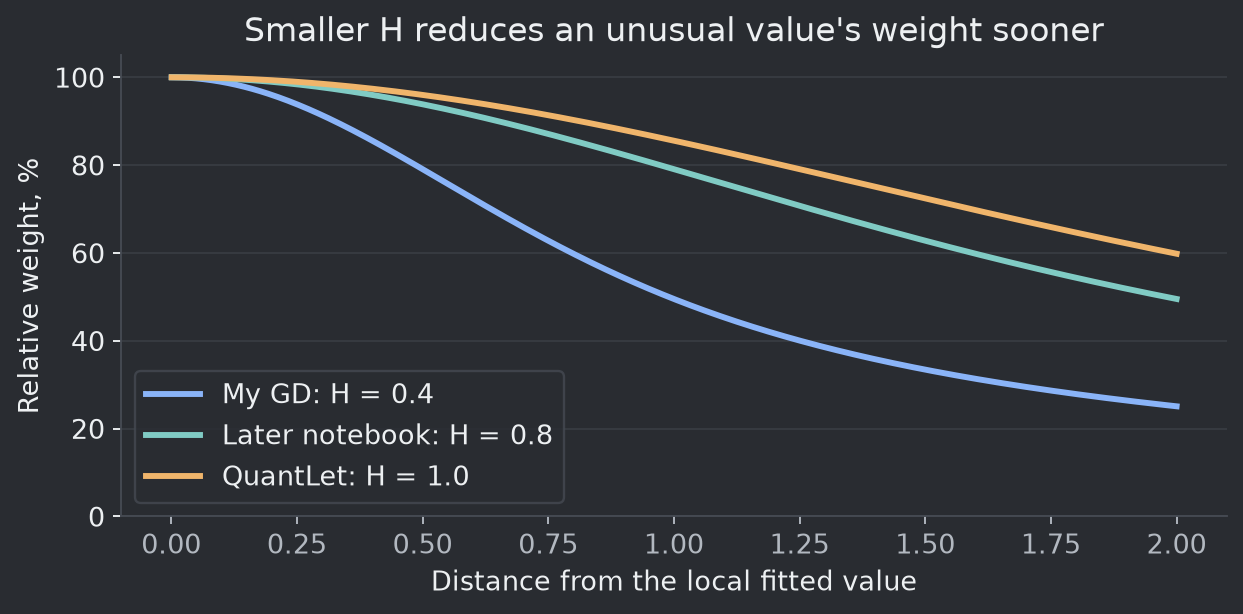

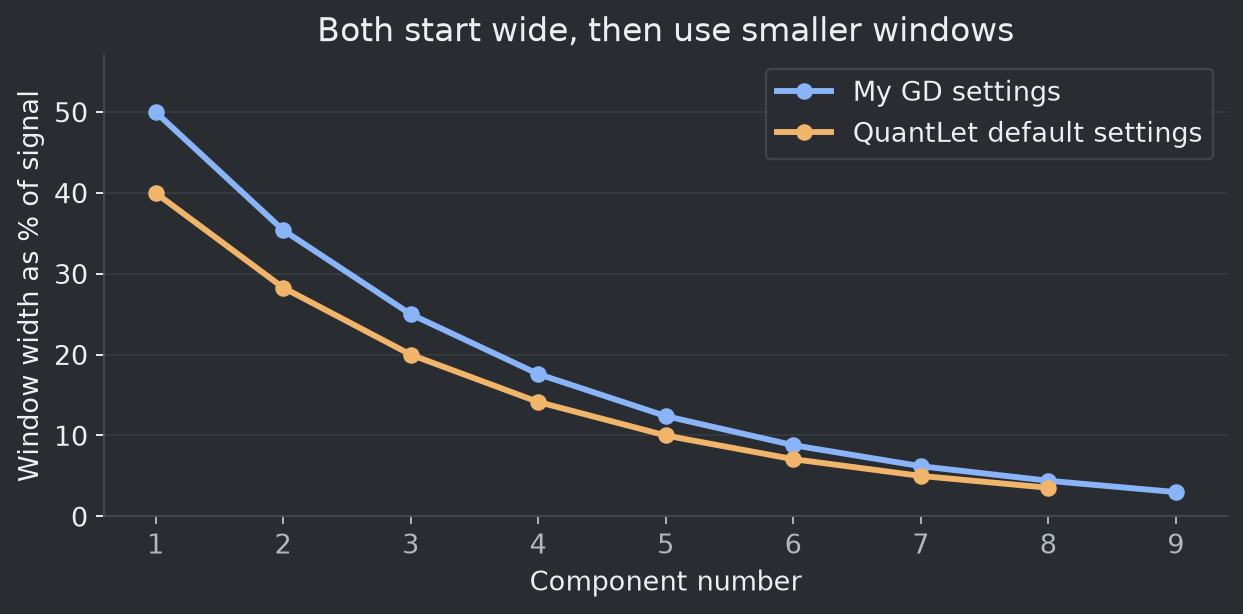

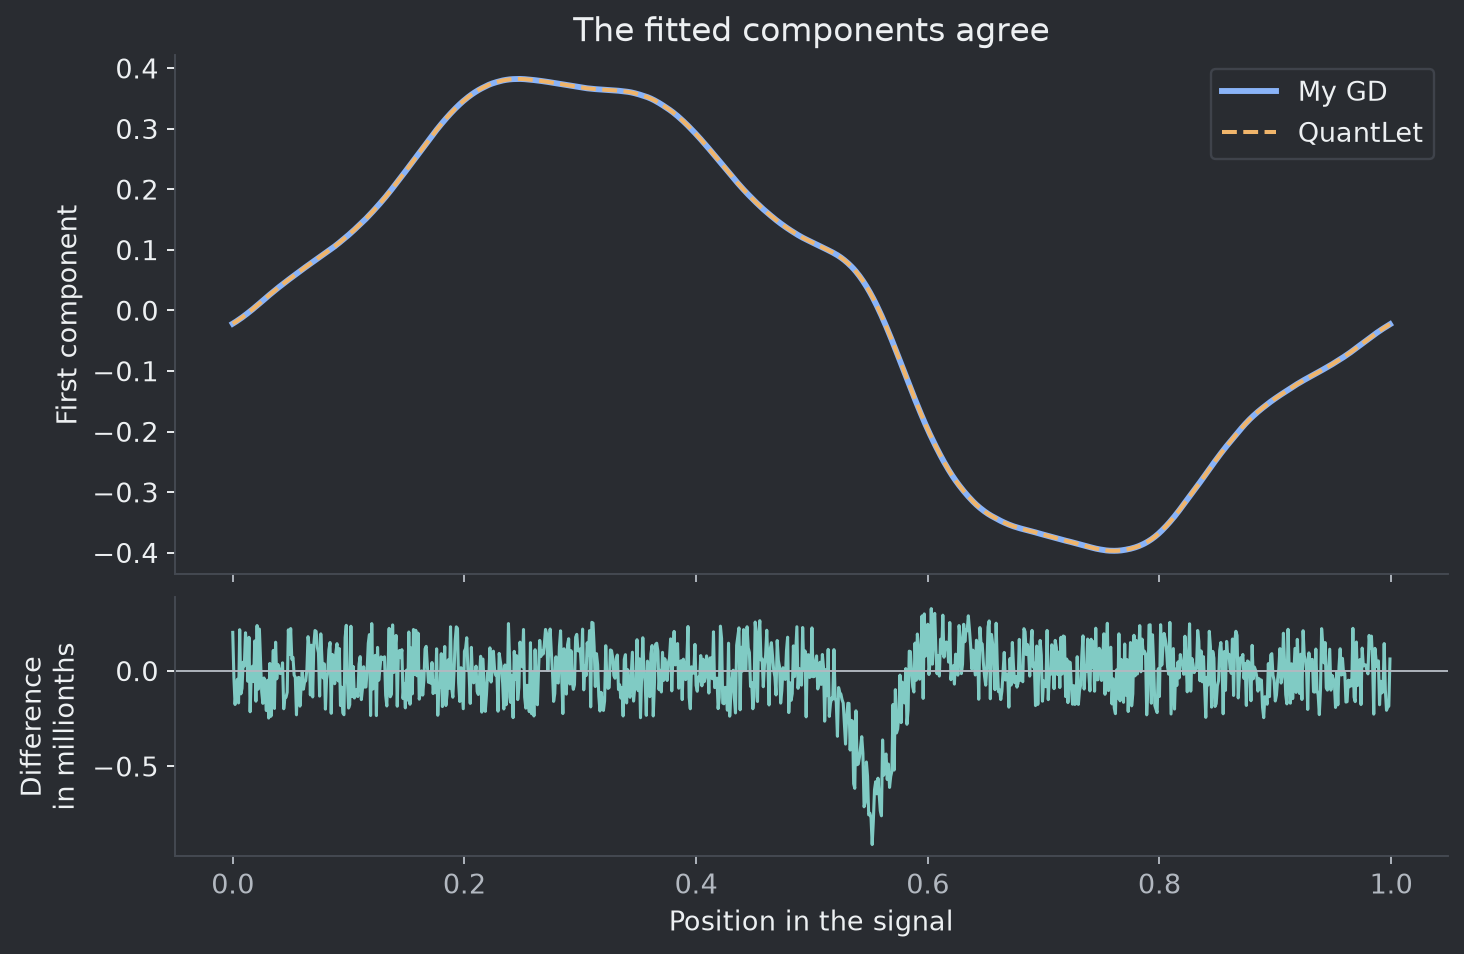

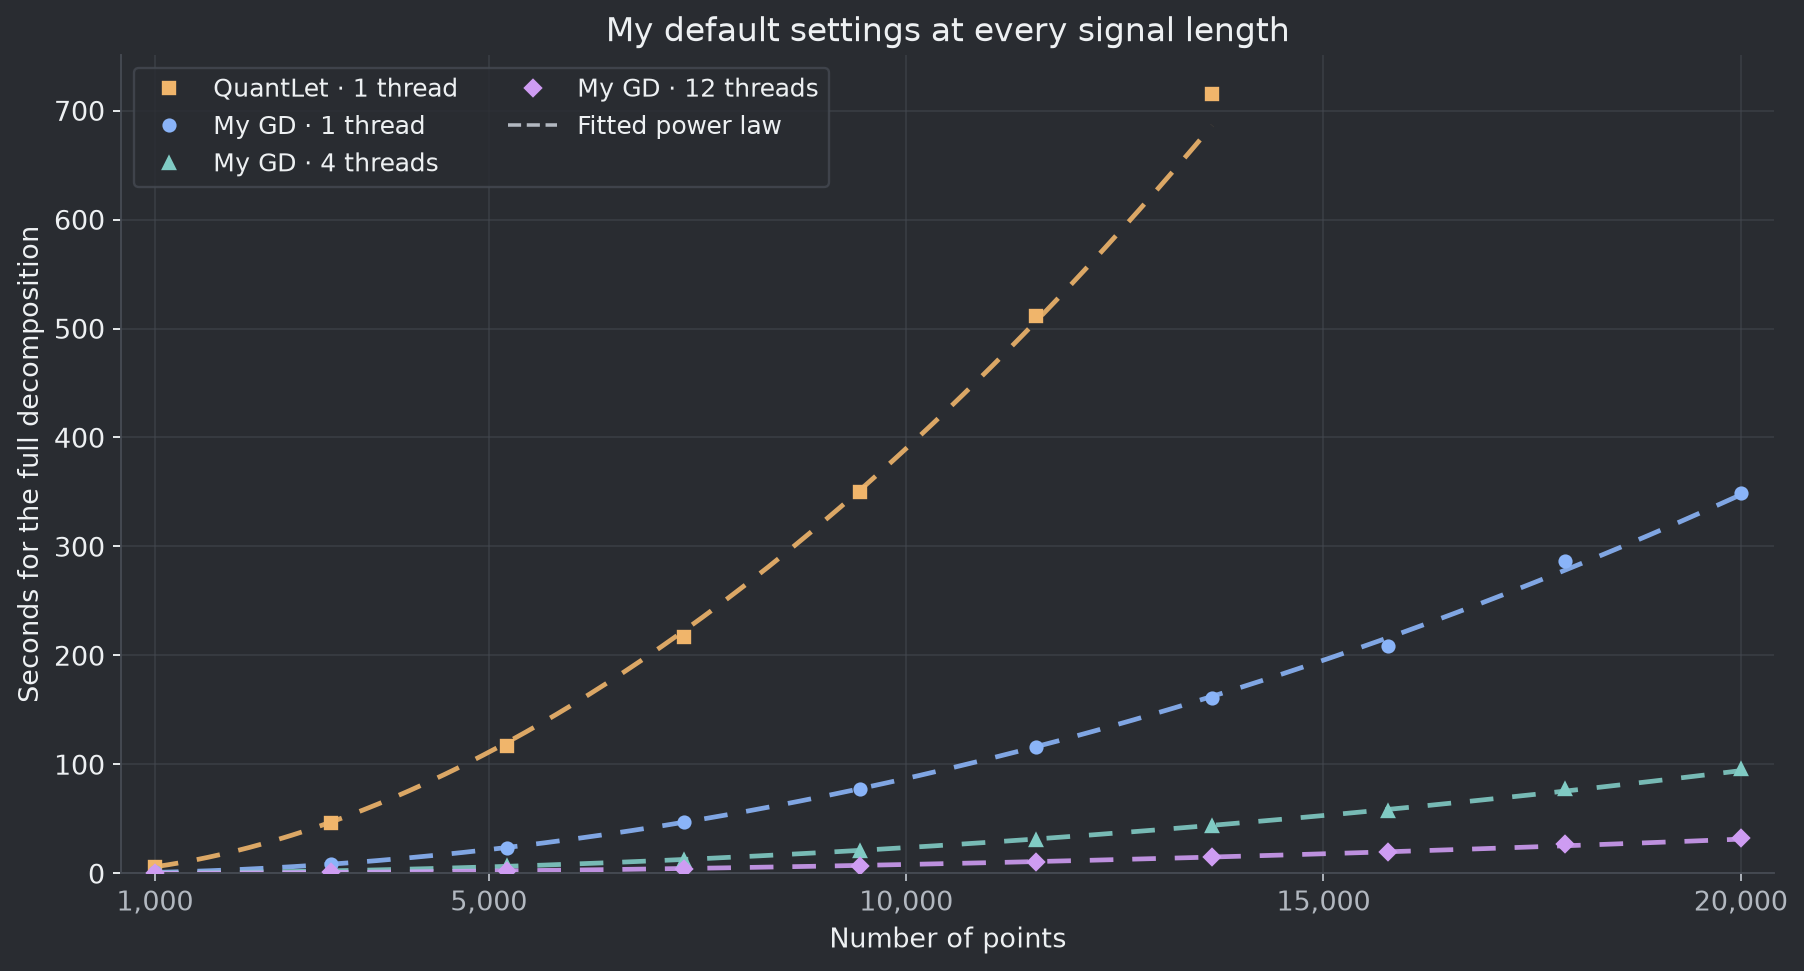

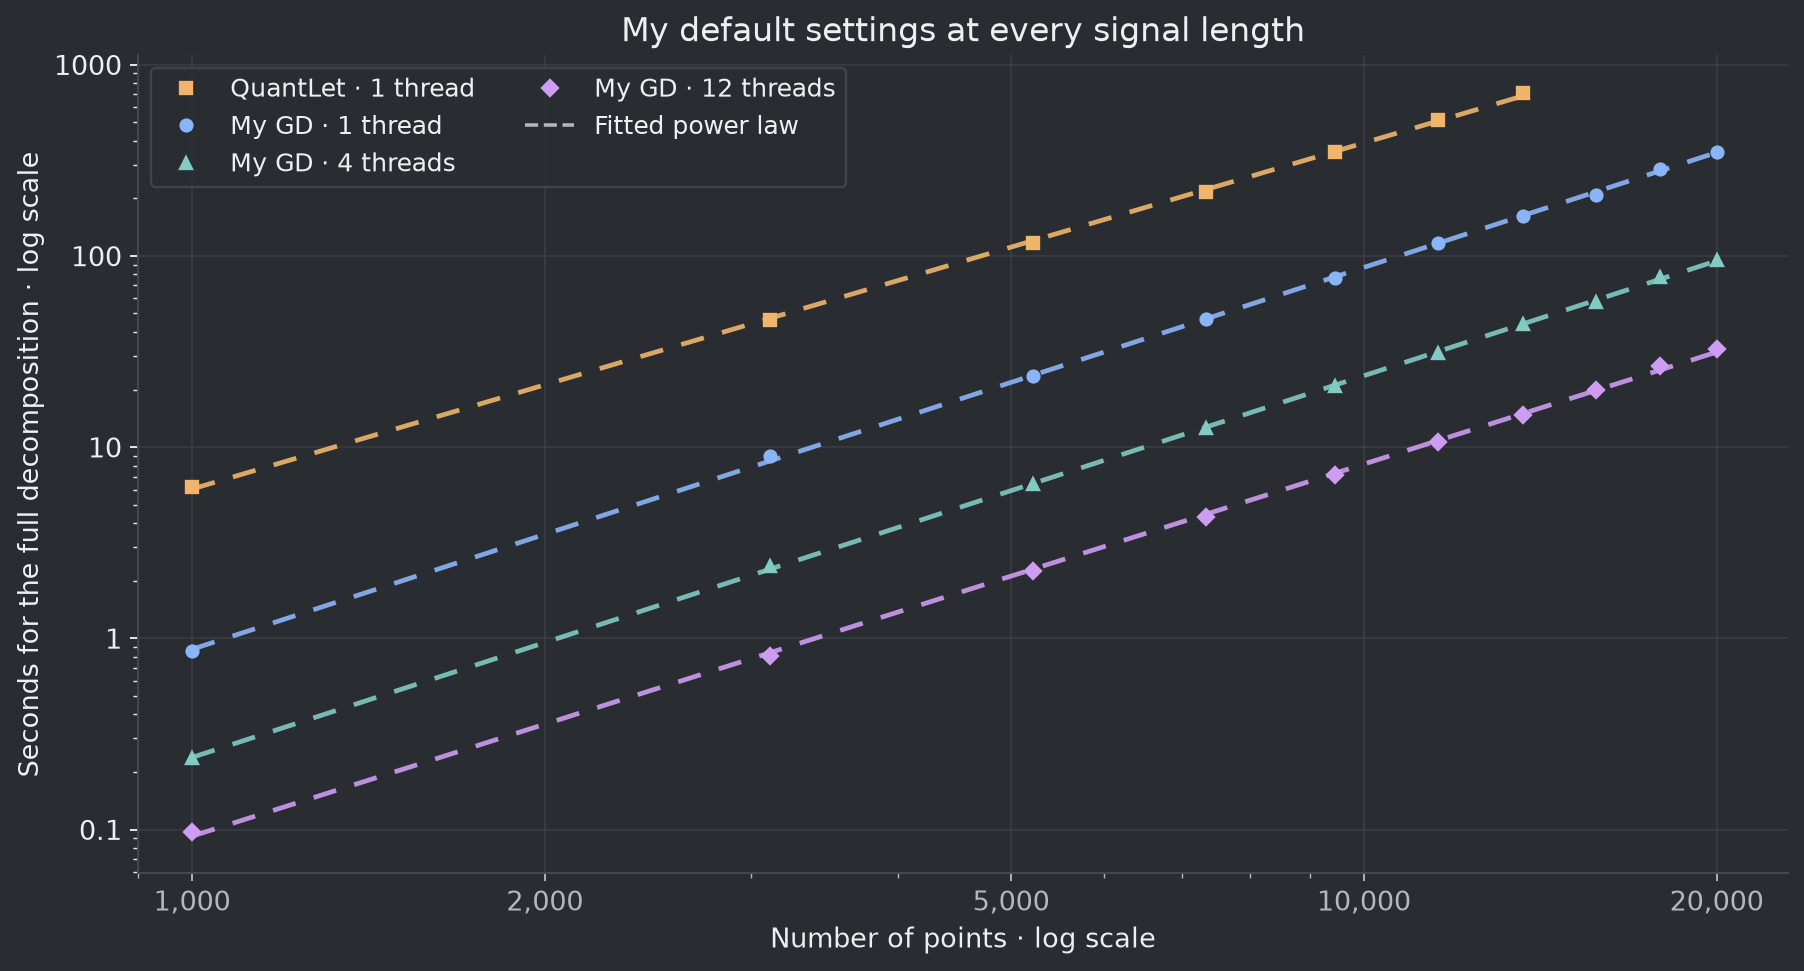

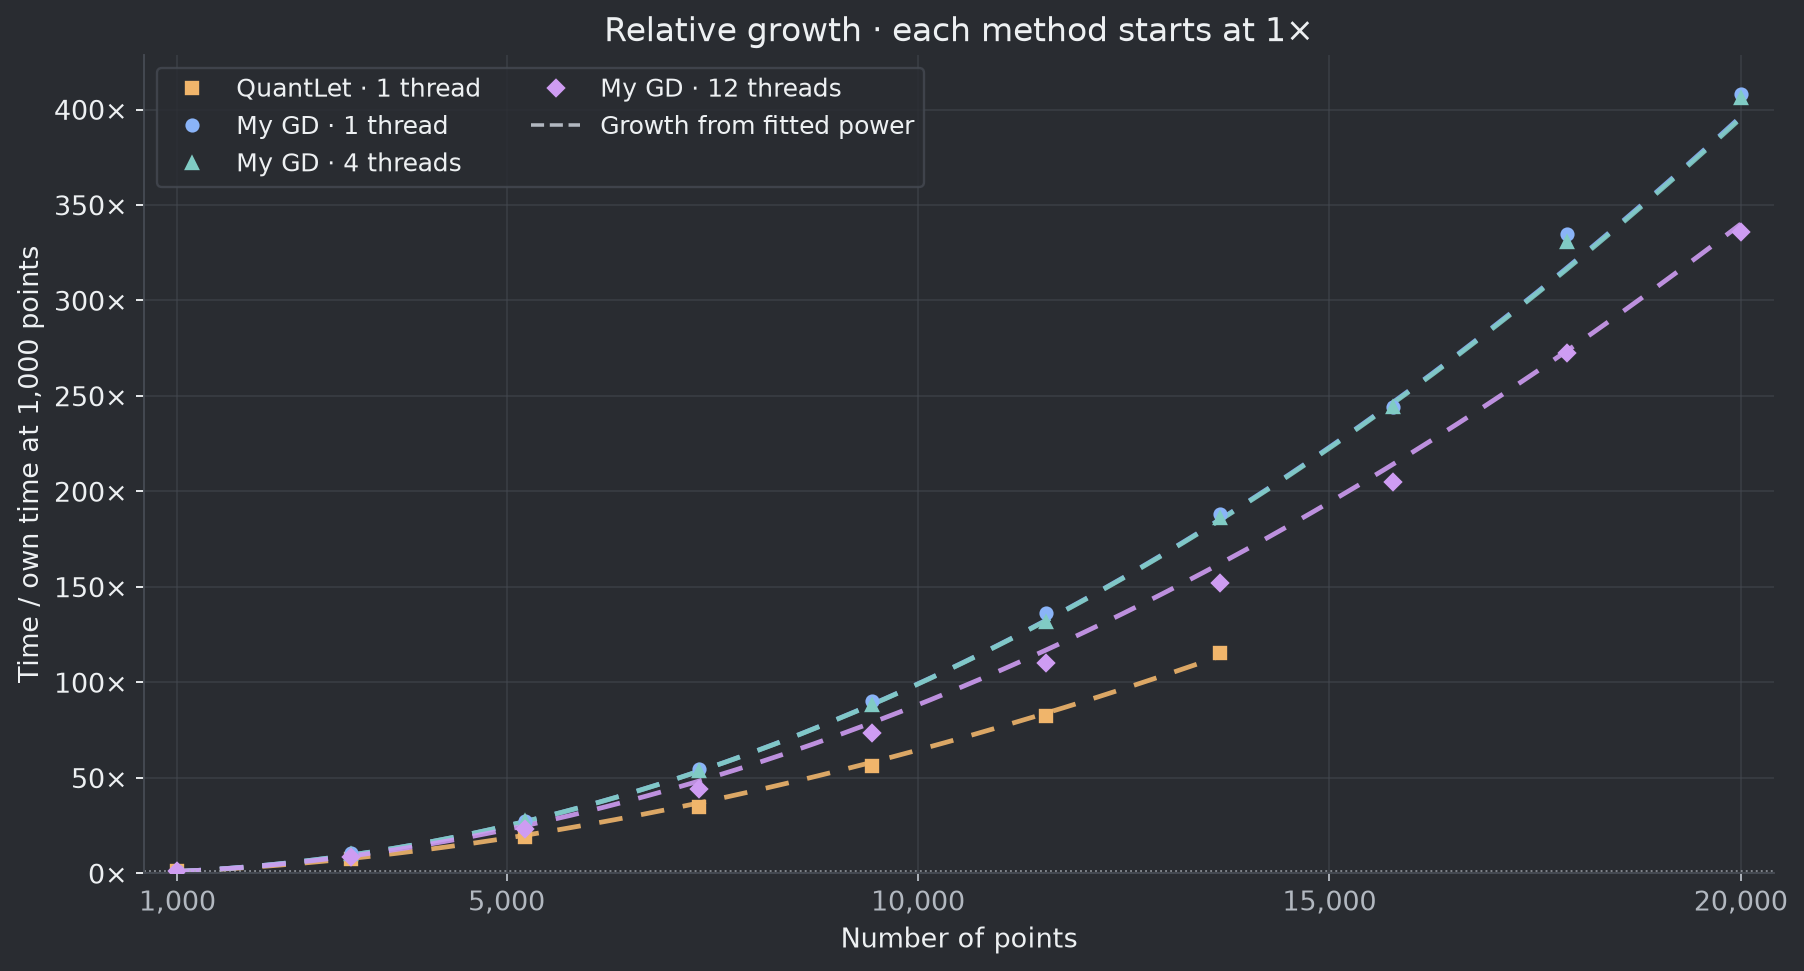

HTML report: /Users/mikhail/Projects/imf/tmp/reports/imf-solver-speed.html


In [8]:
from report_builder import build_report
report_path, figure_paths = build_report(results)
for figure_path in figure_paths:
    # The HTML contains all eight switchable views; show three here.
    if figure_path.stem.startswith("scaling_") and figure_path.stem not in {"scaling_linear_fit", "scaling_loglog_fit", "scaling_relative_linear_fit"}:
        continue
    display(Image(filename=str(figure_path)))
print("HTML report:", report_path)

## Reading the result

The thread-speedup charts compare my GD with its one-thread baseline. The signal-length chart compares full decomposition times across sizes. QuantLet always uses one thread. The fastest thread count is specific to this machine, signal length and input. These are filtering times, not times for QuantLet's full 1000-repetition simulation.

The saved JSON contains the timings, machine details, measurement-time source hashes, per-stage times and validation results. The fit files contain the powers and doubling factors. The original solver files were not edited.